In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
df = pd.read_csv('cl_data.csv')

In [3]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  salary          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
from  sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = lb.fit_transform(df[col])

In [6]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,0
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39,0
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39,0
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,4,0,0,0,38,39,0
32557,40,4,154374,11,9,2,7,0,4,1,0,0,40,39,1
32558,58,4,151910,11,9,6,1,4,4,0,0,0,40,39,0
32559,22,4,201490,11,9,4,1,3,4,1,0,0,20,39,0


In [7]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df2=sc.fit_transform(df)

In [8]:
df2[0]

array([ 0.03067056,  2.15057856, -1.06361075, -0.33543693,  1.13473876,
        0.92163395, -1.3178091 , -0.27780504,  0.39366753,  0.70307135,
        0.1484529 , -0.21665953, -0.03542945,  0.29156857, -0.56319851])

In [9]:
from sklearn.decomposition import PCA

In [10]:
pca = PCA()
pca.fit(df2)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [11]:
explained_var = pca.explained_variance_ratio_

In [12]:
explained_var

array([0.16009525, 0.09640576, 0.08465941, 0.07648624, 0.07154131,
       0.06869838, 0.06564853, 0.06277206, 0.0571247 , 0.05632347,
       0.05095911, 0.04593555, 0.04329632, 0.03473907, 0.02531485])

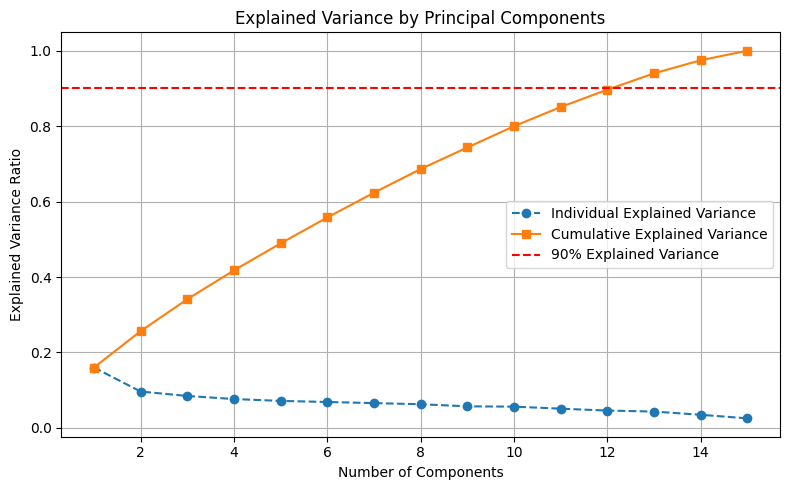

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1,16), explained_var, marker='o', linestyle='--', label='Individual Explained Variance')
plt.plot(range(1,16), explained_var.cumsum(), marker='s', linestyle='-', label='Cumulative Explained Variance')
plt.axhline(y=0.9, color='red', linestyle='--', label='90% Explained Variance')  # 🔴 This is the key addition

plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
pca2 = PCA(n_components=12)
pc_df = pca2.fit_transform(df2)

In [15]:
pc_df.shape

(32561, 12)

In [16]:
pc_df[0]

array([-0.42719909,  0.15324053,  0.63179844,  0.94563545, -0.21650157,
       -0.19972375, -0.5807879 , -1.05254714,  0.265179  , -0.5405915 ,
        1.65878522,  1.26505411])

In [17]:
from sklearn.cluster import KMeans
sse = []
k_range = range(1,13)
for k in k_range:
    km = KMeans(n_clusters=k)
    km.fit(pc_df)
    sse.append(km.inertia_)

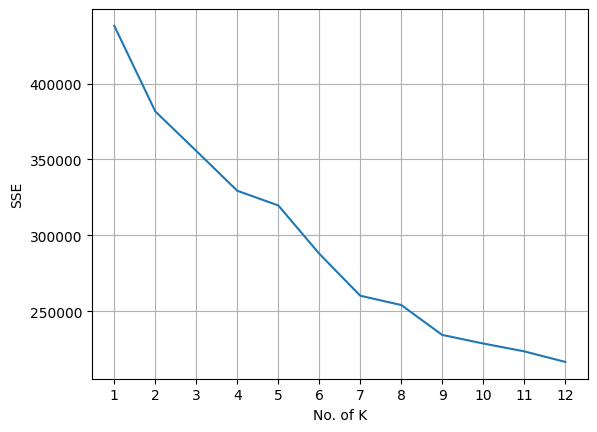

In [18]:
plt.xlabel('No. of K')
plt.ylabel('SSE')
plt.xticks(np.arange(0,13))
plt.grid(True)
plt.plot(k_range,sse)
plt.show()

In [19]:
model = KMeans(n_clusters=3)
model.fit(pc_df)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [20]:
y_pred = model.predict(pc_df)

In [21]:
y_pred

array([1, 1, 1, ..., 2, 2, 0], shape=(32561,), dtype=int32)

In [22]:
pc_df[:,11]

array([ 1.26505411, -0.07522864, -1.19462873, ...,  2.42744292,
       -0.27634189,  0.83109453], shape=(32561,))

In [23]:
pc_df1 = pd.DataFrame(pc_df, columns= [f'Component{i}' for i in range(1,13)])

In [24]:
pc_df1

,Component1,Component2,Component3,Component4,Component5,Component6,Component7,Component8,Component9,Component10,Component11,Component12
0,-0.427199,0.153241,0.631798,0.945635,-0.216502,-0.199724,-0.580788,-1.052547,0.265179,-0.540592,1.658785,1.265054
1,-0.505221,-0.213014,-0.272280,0.984253,-0.860673,0.002622,-0.453777,-0.499182,-1.895516,-0.544943,1.318778,-0.075229
2,-0.554871,-0.742668,-0.343943,0.642511,-0.122931,-0.170249,-0.470611,1.103636,0.163050,0.014809,0.287051,-1.194629
3,0.084546,-2.803998,-0.347255,-1.083909,-0.732114,-0.075059,-0.031131,-0.025230,-0.222738,1.930909,0.160927,0.339545
4,2.006466,0.924904,1.599613,-4.214502,-0.427953,0.580381,-0.485201,1.463636,0.337773,-1.432696,-0.968928,-0.420590
...,...,...,...,...,...,...,...,...,...,...,...,...
32556,1.645189,1.135477,1.290049,0.188184,-1.020673,-0.255102,1.129523,1.170385,0.317019,0.092226,-1.403330,-0.447275
32557,-1.512763,-0.360790,-0.305827,0.367654,0.068685,-0.162553,0.053511,-0.256347,-0.278814,0.001800,-0.300014,0.064318
32558,2.015096,0.762227,-0.908688,0.355972,-0.532641,-0.160219,0.285707,-0.480293,0.002762,-0.451110,0.768426,2.427443
32559,1.819041,-0.039610,-0.152470,0.804986,1.144873,-0.295767,0.138897,-0.518805,-0.302701,-0.432265,1.020202,-0.276342


In [25]:
pc_df1['Labels'] = model.labels_

In [26]:
pc_df1.Labels.value_counts()

Labels
1    15738
2    11949
0     4874
Name: count, dtype: int64

In [30]:
centers = model1.cluster_centers_
centers  

NameError: name 'model1' is not defined

NameError: name 'centers' is not defined

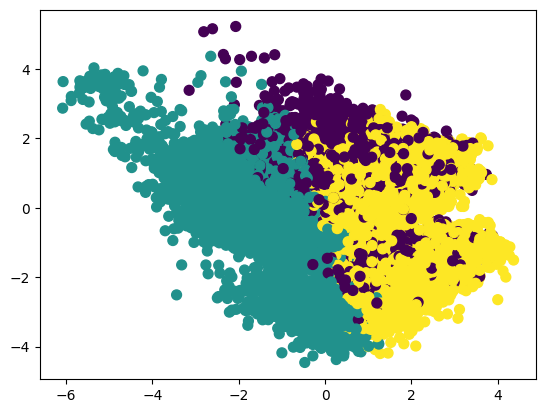

In [28]:
plt.scatter(pc_df1.iloc[:, 0], pc_df1.iloc[:, 1], c=y_pred, s=50, cmap='viridis')


plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

plt.title("KMeans Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

NameError: name 'centers' is not defined

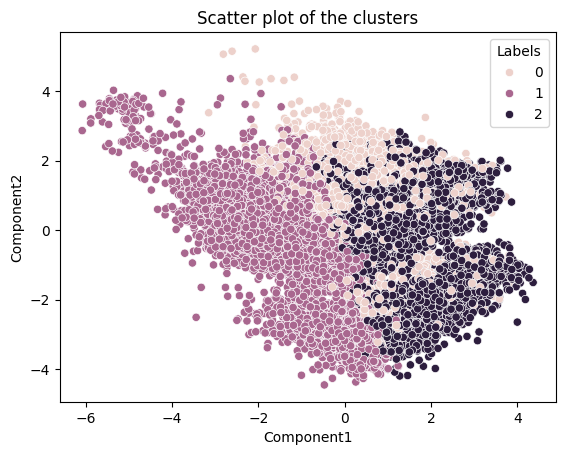

In [29]:
plt.title('Scatter plot of the clusters')
sns.scatterplot(data = pc_df1, x = 'Component1', y = 'Component2', hue='Labels')
plt.scatter(centers[:, 0], centers[:, 1], c = 'red', label = 'Centroids')
plt.show()